# SMLM PCF Pipeline: Plotting & Pooling

This notebook aggregates calculated PCFs across all processed nuclei, computes the pooled average with standard errors, and generates publication-quality plots.

### Steps:
1. **Aggregate**: Scan the output folder for all `*_nucleus_*_pcf.csv` files.
2. **Pool**: Compute mean ± SEM across nuclei for Auto-Left, Auto-Right, and Cross PCF.
3. **Plot**: 3-panel figure with individual curves (thin grey) + pooled mean ± SEM (thick coloured).

### Step 1: Configuration

In [12]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# PARAMETERS - edit these
# ==========================================
results_dir   = '/Volumes/guttman/users/gmgao/Imaging_ProcessedData/SPEN/20260413_ONI-gmgao-SPEN_H3K27ac_dSTORM_SACD/processed-dSTORM/Aux1h'
left_label    = 'SPEN'       # label for left channel
right_label   = 'H3K27ac'    # label for right channel

plot_output_path = os.path.join(results_dir, 'pooled_dstorm_pcf_curves.png')
pooled_csv_path  = os.path.join(results_dir, 'aggregated_pooled_pcf_results.csv')

print('Plotting parameters loaded successfully!')

Plotting parameters loaded successfully!


### Step 2: Load and Pool Individual Nucleus CSVs

In [13]:
csv_files = sorted(glob.glob(os.path.join(results_dir, '*_nucleus_*_pcf.csv')))
print(f'Found {len(csv_files)} nucleus PCF files:')

nucleus_data = []
for f in csv_files:
    df = pd.read_csv(f)
    filename = os.path.basename(f)
    parts    = filename.replace('_pcf.csv', '').split('_nucleus_')
    fov_name = parts[0]
    label_id = parts[1]
    nucleus_data.append({
        'fov':      fov_name,
        'label':    label_id,
        'r_center': df['r_center_nm'].values,
        'G_left':   df['G_auto_left'].values,
        'G_right':  df['G_auto_right'].values,
        'G_cross':  df['G_cross'].values,
    })
    print(f'  Loaded [FOV: {fov_name} | Nucleus: {label_id}]')

if len(nucleus_data) == 0:
    raise ValueError('No PCF files found! Run SMLM_PCF_Processing.ipynb first.')

# Build matrices and compute mean +/- SEM
r_centers  = nucleus_data[0]['r_center']
all_left   = np.array([d['G_left']  for d in nucleus_data])
all_right  = np.array([d['G_right'] for d in nucleus_data])
all_cross  = np.array([d['G_cross'] for d in nucleus_data])
n          = len(nucleus_data)

mean_left,  sem_left  = np.nanmean(all_left,  axis=0), np.nanstd(all_left,  axis=0) / np.sqrt(n)
mean_right, sem_right = np.nanmean(all_right, axis=0), np.nanstd(all_right, axis=0) / np.sqrt(n)
mean_cross, sem_cross = np.nanmean(all_cross, axis=0), np.nanstd(all_cross, axis=0) / np.sqrt(n)

pd.DataFrame({
    'r_center_nm':       r_centers,
    'mean_G_auto_left':  mean_left,  'sem_G_auto_left':  sem_left,
    'mean_G_auto_right': mean_right, 'sem_G_auto_right': sem_right,
    'mean_G_cross':      mean_cross, 'sem_G_cross':      sem_cross,
}).to_csv(pooled_csv_path, index=False)
print(f'\nPooled table saved to: {pooled_csv_path}')

Found 10 nucleus PCF files:
  Loaded [FOV: TXSHA-Aux1h-SPEN_JF549_H3K27ac_DL650-dSTORM-FOV-4 | Nucleus: 1]
  Loaded [FOV: TXSHA-Aux1h-SPEN_JF549_H3K27ac_DL650-dSTORM-FOV-4 | Nucleus: 2]
  Loaded [FOV: TXSHA-Aux1h-SPEN_JF549_H3K27ac_DL650-dSTORM-FOV-4 | Nucleus: 3]
  Loaded [FOV: TXSHA-Aux1h-SPEN_JF549_H3K27ac_DL650-dSTORM-FOV-4 | Nucleus: 4]
  Loaded [FOV: TXSHA-Aux1h-SPEN_JF549_H3K27ac_DL650-dSTORM-FOV-4 | Nucleus: 5]
  Loaded [FOV: TXSHA-Aux1h-SPEN_JF549_H3K27ac_DL650-dSTORM-FOV-4 | Nucleus: 6]
  Loaded [FOV: TXSHA-Aux1h-SPEN_JF549_H3K27ac_DL650-dSTORM-FOV | Nucleus: 1]
  Loaded [FOV: TXSHA-Aux1h-SPEN_JF549_H3K27ac_DL650-dSTORM-FOV | Nucleus: 2]
  Loaded [FOV: TXSHA-Aux1h-SPEN_JF549_H3K27ac_DL650-dSTORM-FOV | Nucleus: 3]
  Loaded [FOV: TXSHA-Aux1h-SPEN_JF549_H3K27ac_DL650-dSTORM-FOV | Nucleus: 4]

Pooled table saved to: /Volumes/guttman/users/gmgao/Imaging_ProcessedData/SPEN/20260413_ONI-gmgao-SPEN_H3K27ac_dSTORM_SACD/processed-dSTORM/Aux1h/aggregated_pooled_pcf_results.csv


### Step 3: Publication-Quality 3-Panel Figure

Plot saved to: /Volumes/guttman/users/gmgao/Imaging_ProcessedData/SPEN/20260413_ONI-gmgao-SPEN_H3K27ac_dSTORM_SACD/processed-dSTORM/Aux1h/pooled_dstorm_pcf_curves.png


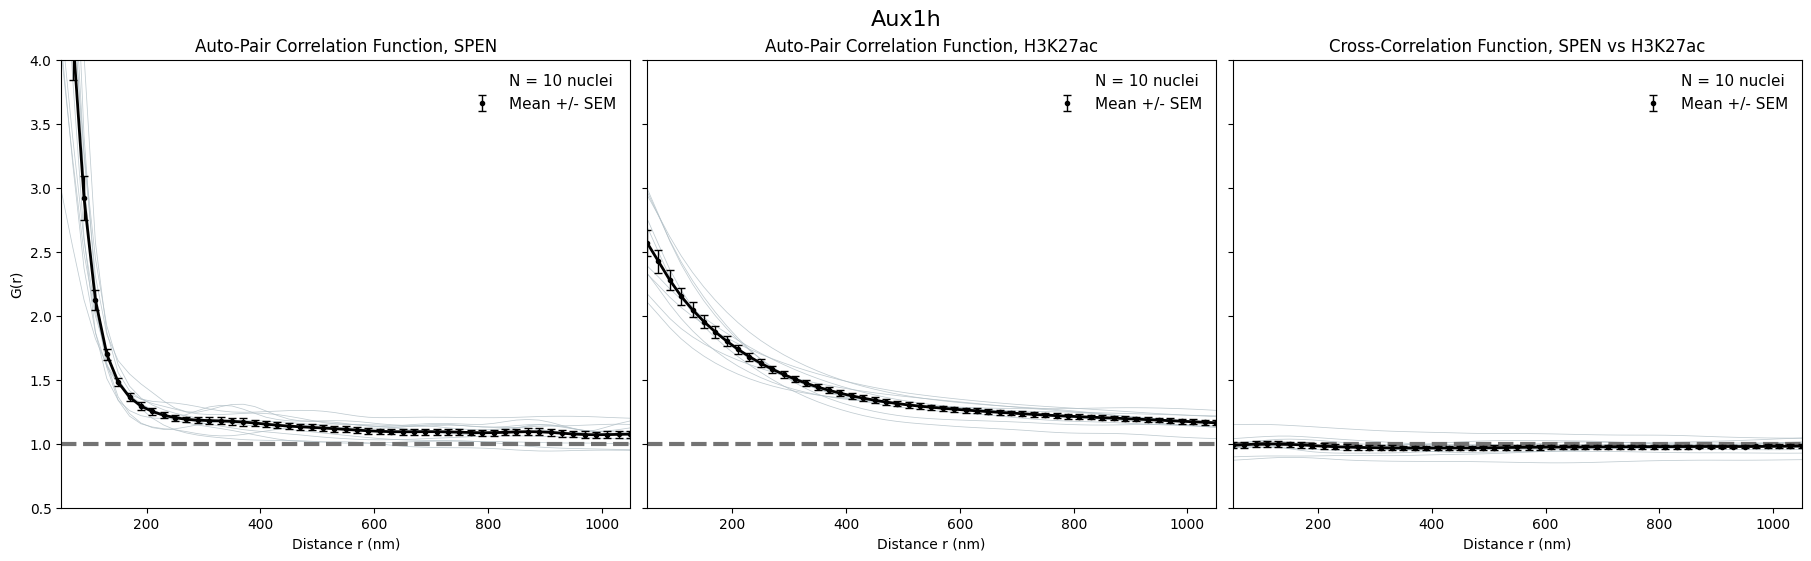

In [14]:
def clamp_pcf_ylim(ax, lower=0.5, upper=4.0):
    y0, y1 = ax.get_ylim()
    if y0 < lower or y1 > upper:
        ax.set_ylim(lower, upper)


def plot_pcf_mean_with_sem(ax, x, mean, sem, color, label, zorder=4):
    ax.errorbar(
        x,
        mean,
        yerr=sem,
        fmt='.',
        color=color,
        ecolor=color,
        elinewidth=1,
        capsize=3,
        # alpha=0.5,
        label=label,
        zorder=zorder,
    )
    ax.plot(x, mean, color=color, lw=2, zorder=zorder)


fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), constrained_layout=True, sharex=True, sharey=True)
r_min, r_max_plot = r_centers.min(), r_centers.max()

panel_cfg = [
    ('G_left',  all_left,  mean_left,  sem_left,
     f'Auto-Pair Correlation Function, {left_label}'),
    ('G_right', all_right, mean_right, sem_right,
     f'Auto-Pair Correlation Function, {right_label}'),
    ('G_cross', all_cross, mean_cross, sem_cross,
     f'Cross-Correlation Function, {left_label} vs {right_label}'),
]

for ax, (gkey, all_g, mean_g, sem_g, title) in zip(axes, panel_cfg):
    # Individual nuclei - RDF aggregate background style
    for d in nucleus_data:
        ax.plot(r_centers, d[gkey], color='#b0bec5', alpha=0.8, linewidth=0.55, zorder=1)

    plot_pcf_mean_with_sem(ax, r_centers, mean_g, sem_g, 'black', 'Mean +/- SEM', zorder=4)
    ax.axhline(1, color='0.45', ls='--', lw=3)
    ax.set_xlim(r_min, r_max_plot)
    ax.set_title(title)
    ax.set_xlabel('Distance r (nm)')
    clamp_pcf_ylim(ax)
    ax.plot([], [], linestyle='None', label=f'N = {n} nuclei')
    ax.legend(frameon=False, fontsize=11, loc='best')

axes[0].set_ylabel('G(r)')
plt.suptitle(os.path.basename(results_dir), fontsize=16)
fig.savefig(plot_output_path, dpi=300, bbox_inches='tight')
print(f'Plot saved to: {plot_output_path}')
plt.show()

